# Module 2 End Project

In [24]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

In [25]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt

url="https://docs.google.com/spreadsheets/d/1aDiNQMStFPyY7mJEgt2sIAApFrG2uE19/export?format=csv"

df=pd.read_csv(url)

print(df.head())



            Name            Team  Number Position  Age  Height  Weight  \
0  Avery Bradley  Boston Celtics       0       PG   25  06-Feb     180   
1    Jae Crowder  Boston Celtics      99       SF   25  06-Jun     235   
2   John Holland  Boston Celtics      30       SG   27  06-May     205   
3    R.J. Hunter  Boston Celtics      28       SG   22  06-May     185   
4  Jonas Jerebko  Boston Celtics       8       PF   29  06-Oct     231   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4                NaN  5000000.0  


### Preprocessing

* Correct the data in the "height" column by replacing it with random numbers between 150 and 180. Ensure data consistency and integrity before proceeding with analysis.

In [26]:
df['height']=[random.randint(150,180) for _ in range(len(df))]

print(df[['height']].head())

   height
0     172
1     151
2     174
3     161
4     155


### Analysis Task 1

* Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees.

                        Count  Percentage (%)
Team                                         
New Orleans Pelicans       19        4.148472
Memphis Grizzlies          18        3.930131
Utah Jazz                  16        3.493450
New York Knicks            16        3.493450
Milwaukee Bucks            16        3.493450
Brooklyn Nets              15        3.275109
Portland Trail Blazers     15        3.275109
Oklahoma City Thunder      15        3.275109
Denver Nuggets             15        3.275109
Washington Wizards         15        3.275109
Miami Heat                 15        3.275109
Charlotte Hornets          15        3.275109
Atlanta Hawks              15        3.275109
San Antonio Spurs          15        3.275109
Houston Rockets            15        3.275109
Boston Celtics             15        3.275109
Indiana Pacers             15        3.275109
Detroit Pistons            15        3.275109
Cleveland Cavaliers        15        3.275109
Chicago Bulls              15     

C:\Users\Nimish\AppData\Local\Temp\ipykernel_12256\152341295.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Team', order=df['Team'].value_counts().index, palette='viridis')


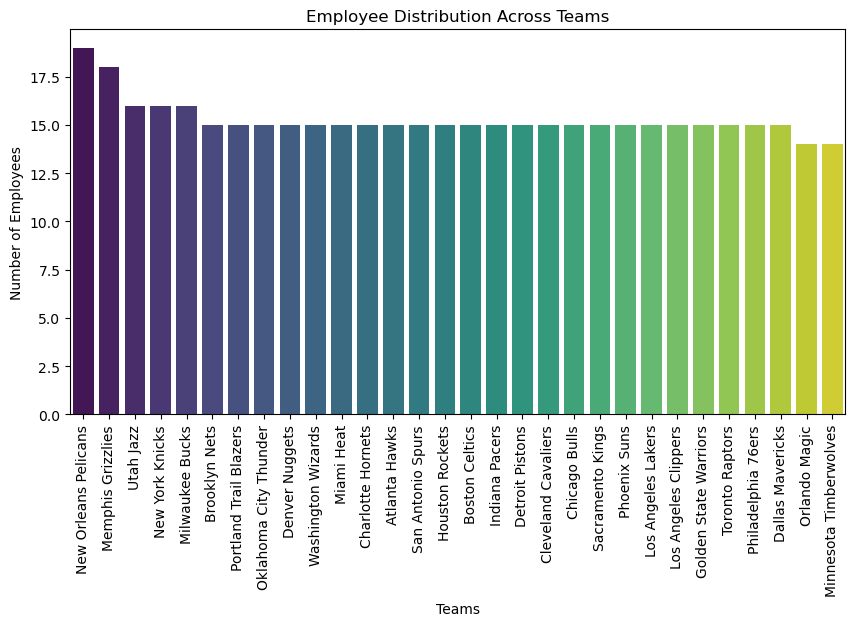

In [27]:
team_counts = df['Team'].value_counts()
team_percentage = df['Team'].value_counts(normalize=True) * 100

team_summary = pd.DataFrame({'Count': team_counts, 'Percentage (%)': team_percentage})
print(team_summary)


plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Team', order=df['Team'].value_counts().index, palette='viridis')
plt.title('Employee Distribution Across Teams')
plt.xlabel('Teams')
plt.ylabel('Number of Employees')
plt.xticks(rotation=90)
plt.show()

Observation: The analysis of team-wise employee distribution and percentages reveals that certain teams have a higher concentration of employees, while others have fewer members.


### Analysis Task 2

*  Segregate employees based on their positions within the company.

Position-wise Employee Distribution:
Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


C:\Users\Nimish\AppData\Local\Temp\ipykernel_12256\3493544639.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Position', order=position_counts.index, palette='crest')


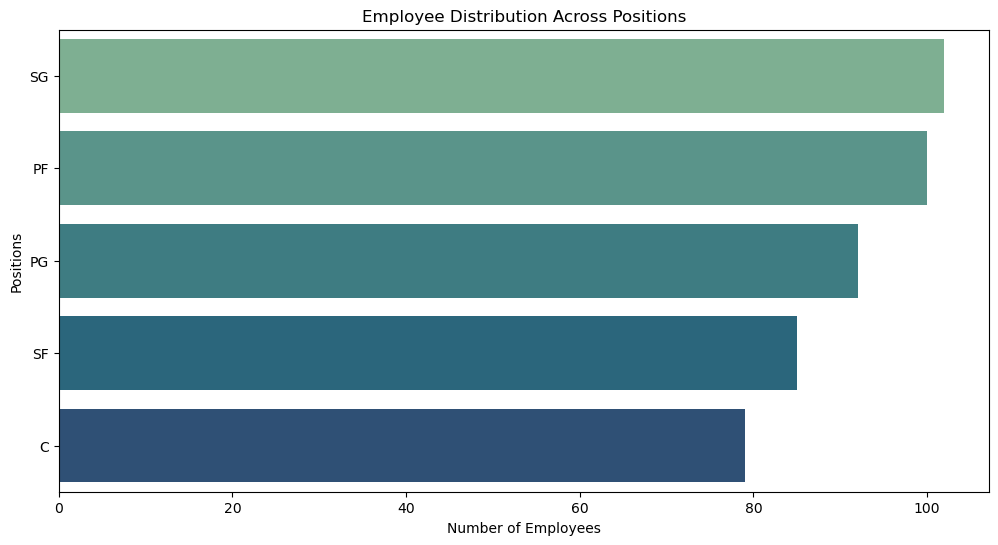

In [28]:
position_counts = df['Position'].value_counts()
print("Position-wise Employee Distribution:")
print(position_counts)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Position', order=position_counts.index, palette='crest')
plt.title('Employee Distribution Across Positions')
plt.xlabel('Number of Employees')
plt.ylabel('Positions')
plt.show()

​Observation: Segregating employees by their positions provides clear insights into which designations have the highest staffing levels and which have fewer personnel within the company.

### Analysis Task 3

* Identify the predominant age group among employees.

Minimum Age: 19
Maximum Age: 40

Age Group Distribution:
Age_Group
20-30    334
30-40    119
40-50      3
50-60      0
Name: count, dtype: int64


C:\Users\Nimish\AppData\Local\Temp\ipykernel_12256\1892221538.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age_Group', palette='Set2')


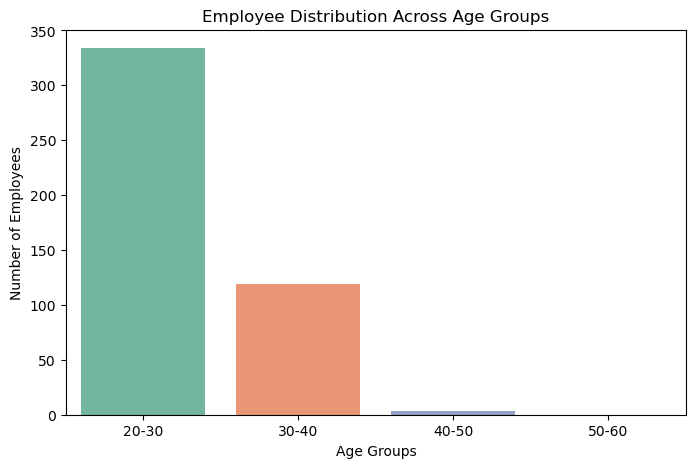

In [29]:
print("Minimum Age:", df['Age'].min())
print("Maximum Age:", df['Age'].max())

bins = [20, 30, 40, 50, 60]
labels = ['20-30', '30-40', '40-50', '50-60']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_group_counts = df['Age_Group'].value_counts().sort_index()
print("\nAge Group Distribution:")
print(age_group_counts)


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age_Group', palette='Set2')
plt.title('Employee Distribution Across Age Groups')
plt.xlabel('Age Groups')
plt.ylabel('Number of Employees')
plt.show()

​Observation: The age distribution analysis clearly indicates that the majority of the company's employees fall within the 20-30 age group, making it the predominant age bracket.

### Analysis Task 4 

* Discover which team and position have the highest salary expenditure.Discover which team and position have the highest salary expenditure.

Team with Highest Salary Expenditure:
Team      Cleveland Cavaliers
Salary            106988689.0
Name: 5, dtype: object

Position with Highest Salary Expenditure:
Position              C
Salary      466377332.0
Name: 0, dtype: object


C:\Users\Nimish\AppData\Local\Temp\ipykernel_12256\735291513.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_salary, x='Team', y='Salary', palette='magma')


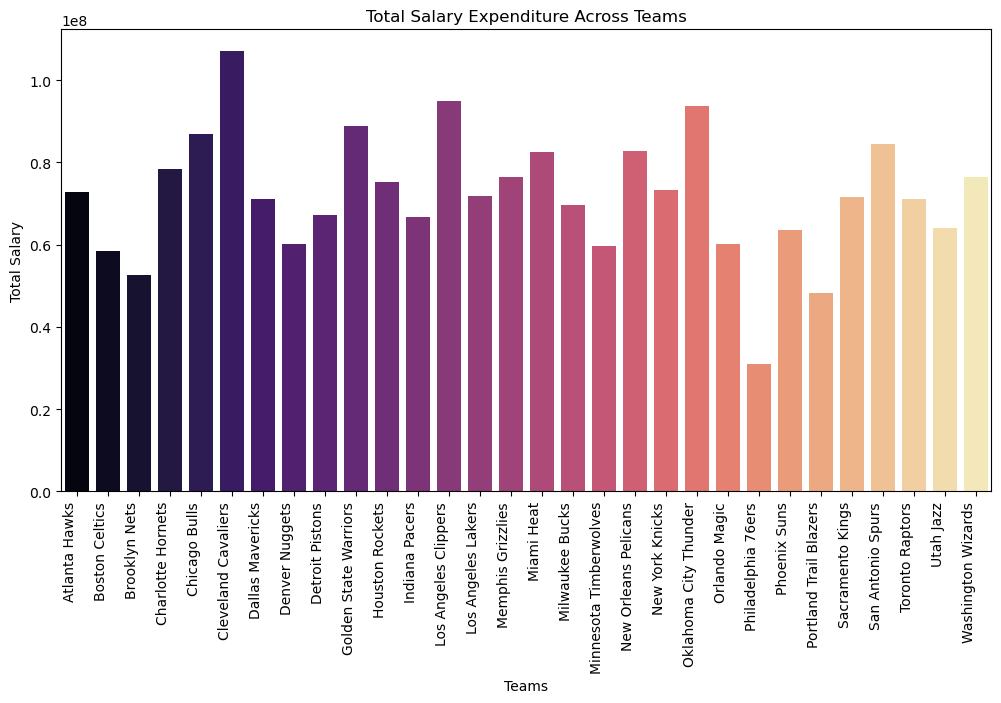

In [30]:
team_salary = df.groupby('Team')['Salary'].sum().reset_index()
highest_salary_team = team_salary.loc[team_salary['Salary'].idxmax()]

print("Team with Highest Salary Expenditure:")
print(highest_salary_team)

position_salary = df.groupby('Position')['Salary'].sum().reset_index()
highest_salary_position = position_salary.loc[position_salary['Salary'].idxmax()]

print("\nPosition with Highest Salary Expenditure:")
print(highest_salary_position)

plt.figure(figsize=(12, 6))
sns.barplot(data=team_salary, x='Team', y='Salary', palette='magma')
plt.title('Total Salary Expenditure Across Teams')
plt.xlabel('Teams')
plt.ylabel('Total Salary')
plt.xticks(rotation=90, ha='right')
plt.show()

​Observation: Identifying the teams and positions with the highest salary expenditure highlights where the company allocates the majority of its payroll budget.

### Analysis Task 5

* Investigate if there's any correlation between age and salary, and
represent it visually.

Correlation between Age and Salary: 0.21400941226570974


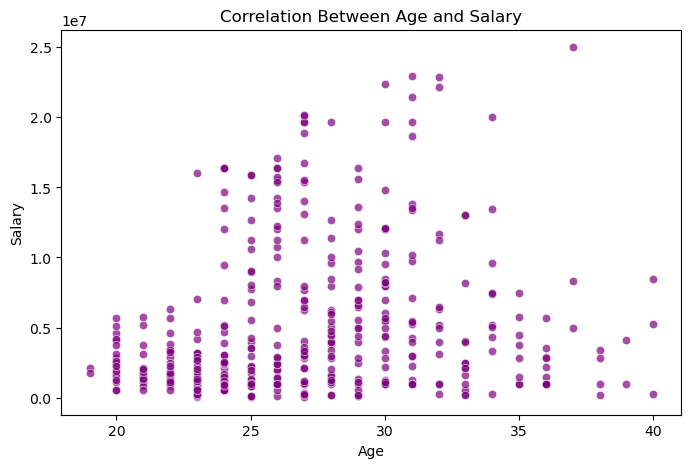

In [31]:
correlation = df['Age'].corr(df['Salary'])
print("Correlation between Age and Salary:", correlation)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Salary', color='purple', alpha=0.7)
plt.title('Correlation Between Age and Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()

​Observation: The scatter plot and correlation value between age and salary show a very weak correlation, indicating that age is not a primary factor determining salary levels in this dataset.